# Brain MRI Segmentation — Classical + Deep Learning (U-Net)
**Dataset:** LGG Brain MRI Segmentation (mateuszbuda/lgg-mri-segmentation)

**Implemented Algorithms:**
- Otsu Thresholding
- K-means Clustering
- Canny Edge Detection + post-processing
- **U-Net (Deep Learning)**

**Evaluation Metrics:**
- Dice Coefficient
- IoU (Jaccard Index)
- Precision, Recall, F1-score, Accuracy

## 1. Install & Import Libraries

In [ ]:
# Install required libraries 
# !pip install opencv-python scikit-image scikit-learn matplotlib numpy pandas tqdm torch torchvision

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from sklearn.cluster import KMeans

# PyTorch imports for U-Net
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Display settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Libraries loaded successfully')
print(f'Device: {DEVICE}')

Libraries loaded successfully
Device: cpu


## 2. Load Dataset

In [2]:
# --------------------------------
# Set your dataset path here
# If running on Kaggle:
DATASET_PATH = '/kaggle/input/lgg-mri-segmentation/kaggle_3m'
# If running locally:
DATASET_PATH = "C:\\Users\\amazonshop\\Desktop\\tumor_detector\\kaggle_3m"
# --------------------------------

# Find all MRI images (exclude masks)
all_image_paths = sorted([
    p for p in glob(os.path.join(DATASET_PATH, '**', '*.tif'), recursive=True)
    if '_mask' not in p
])

# Find corresponding mask for each image
all_mask_paths = [p.replace('.tif', '_mask.tif') for p in all_image_paths]

# Keep only pairs where both files exist
valid_pairs = [
    (img, msk) for img, msk in zip(all_image_paths, all_mask_paths)
    if os.path.exists(msk)
]

print(f'Total valid image-mask pairs: {len(valid_pairs)}')

# Keep only images that contain a tumor (non-zero mask)
tumor_pairs = []
for img_path, msk_path in tqdm(valid_pairs, desc='Filtering tumor images'):
    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    if mask is not None and mask.max() > 0:
        tumor_pairs.append((img_path, msk_path))

print(f'Images with tumor: {len(tumor_pairs)}')

# Train/val/test split (70% / 15% / 15%)
np.random.seed(42)
indices = np.random.permutation(len(tumor_pairs))
n = len(tumor_pairs)
train_pairs = [tumor_pairs[i] for i in indices[:int(0.70 * n)]]
val_pairs   = [tumor_pairs[i] for i in indices[int(0.70 * n):int(0.85 * n)]]
test_pairs  = [tumor_pairs[i] for i in indices[int(0.85 * n):]]

print(f'\nSplit: Train={len(train_pairs)} | Val={len(val_pairs)} | Test={len(test_pairs)}')

# For classical algorithms, use the test set (50 samples max for speed)
N_CLASSICAL = 50
classical_pairs = test_pairs[:N_CLASSICAL]

Total valid image-mask pairs: 3929


Filtering tumor images: 100%|██████████| 3929/3929 [00:02<00:00, 1795.56it/s]

Images with tumor: 1373

Split: Train=961 | Val=206 | Test=206


## 3. Preprocessing

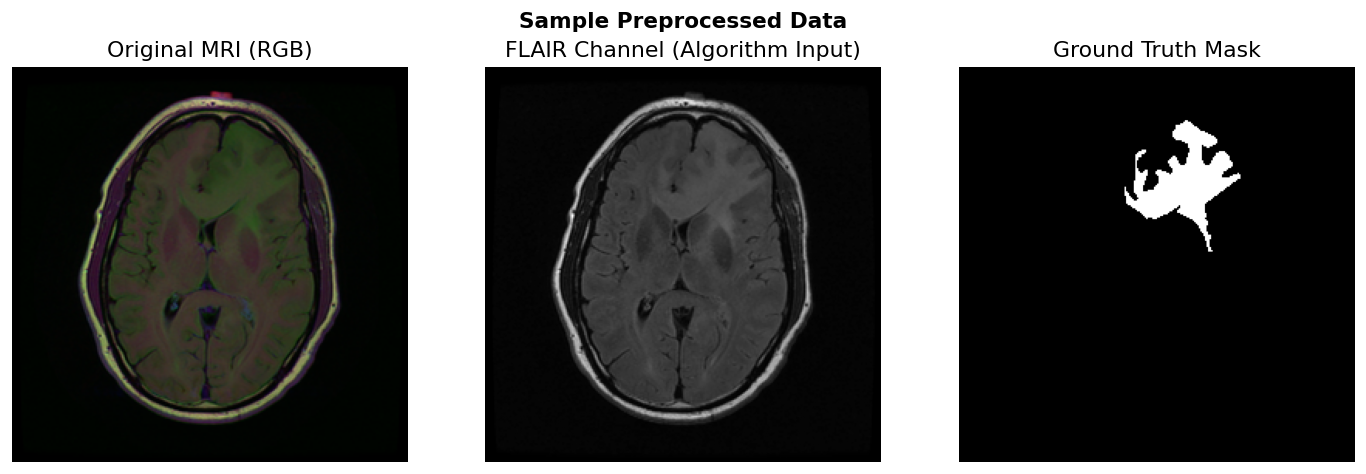

Preprocessing successful


In [3]:
IMG_SIZE = 256  # standard size for all algorithms

def preprocess_image(img_path, size=IMG_SIZE):
    """Load and preprocess an MRI image. Returns (rgb_img, flair_channel)."""
    # .tif files have 3 channels: pre-contrast, FLAIR, post-contrast
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    img = cv2.resize(img, (size, size))
    # FLAIR channel (index 1) — tumors appear hyperintense here
    flair = img[:, :, 1]
    flair_norm = cv2.normalize(flair, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return img, flair_norm

def preprocess_mask(msk_path, size=IMG_SIZE):
    """Load and binarize a ground truth mask."""
    mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    return (mask > 127).astype(np.uint8)

# Verify preprocessing on one sample
test_img, test_flair = preprocess_image(classical_pairs[0][0])
test_mask = preprocess_mask(classical_pairs[0][1])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original MRI (RGB)'); axes[0].axis('off')
axes[1].imshow(test_flair, cmap='gray')
axes[1].set_title('FLAIR Channel (Algorithm Input)'); axes[1].axis('off')
axes[2].imshow(test_mask, cmap='gray')
axes[2].set_title('Ground Truth Mask'); axes[2].axis('off')
plt.suptitle('Sample Preprocessed Data', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('Preprocessing successful')

## 4. Evaluation Metrics

In [4]:
def compute_metrics(pred_mask, gt_mask):
    """
    Compute segmentation evaluation metrics.
    Both inputs should be binary numpy arrays (0 or 1).
    """
    pred = pred_mask.flatten().astype(bool)
    gt   = gt_mask.flatten().astype(bool)

    TP = (pred & gt).sum()
    FP = (pred & ~gt).sum()
    FN = (~pred & gt).sum()
    TN = (~pred & ~gt).sum()

    dice      = (2 * TP) / (2 * TP + FP + FN + 1e-8)
    iou       = TP / (TP + FP + FN + 1e-8)
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-8)

    return {
        'Dice':      round(float(dice), 4),
        'IoU':       round(float(iou), 4),
        'Precision': round(float(precision), 4),
        'Recall':    round(float(recall), 4),
        'F1':        round(float(f1), 4),
        'Accuracy':  round(float(accuracy), 4)
    }

print('Evaluation metrics defined')

Evaluation metrics defined


## 5. Classical Algorithms

### 5.1 Otsu Thresholding

In [5]:
def segment_otsu(flair_img):
    """
    Otsu Thresholding:
    Automatically finds the optimal threshold that maximizes
    inter-class variance between tumor and background pixels.
    """
    blurred = cv2.GaussianBlur(flair_img, (5, 5), 0)
    thresh_val, binary = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    # Morphological cleanup: remove small noise, fill holes
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    # Keep only the largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        result = (labels == largest).astype(np.uint8)
    else:
        result = (cleaned > 0).astype(np.uint8)
    return result, thresh_val

print('Otsu defined')

Otsu defined


### 5.2 K-means Clustering

In [6]:
def segment_kmeans(flair_img, k=3):
    """
    K-means Clustering:
    Groups pixels into k clusters by intensity.
    The brightest cluster is selected as the tumor region
    (FLAIR tumors are hyperintense).
    """
    pixels = flair_img.reshape(-1, 1).astype(np.float32)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pixels)
    segmented = labels.reshape(flair_img.shape)
    # Select cluster with highest mean intensity
    cluster_means = [flair_img[segmented == i].mean() for i in range(k)]
    tumor_cluster = np.argmax(cluster_means)
    binary = (segmented == tumor_cluster).astype(np.uint8)
    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    # Keep largest connected component
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        result = (labels_cc == largest).astype(np.uint8)
    else:
        result = cleaned
    return result, cluster_means

print('K-means defined')

K-means defined


### 5.3 Canny Edge Detection

In [7]:
def segment_canny(flair_img):
    """
    Canny Edge Detection + Post-processing:
    Detects tumor boundaries, then uses flood fill to
    create a solid segmentation mask from the edge map.
    """
    blurred = cv2.GaussianBlur(flair_img, (7, 7), 1.5)
    # Adaptive thresholds based on image median
    median_val = np.median(blurred)
    lower = int(max(0, 0.5 * median_val))
    upper = int(min(255, 1.5 * median_val))
    edges = cv2.Canny(blurred, lower, upper)
    # Dilate to close edge gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    dilated = cv2.dilate(edges, kernel, iterations=2)
    # Flood fill to create solid regions
    filled = dilated.copy()
    h, w = filled.shape
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(filled, flood_mask, (0, 0), 255)
    filled_inv = cv2.bitwise_not(filled)
    result_raw = cv2.bitwise_or(dilated, filled_inv)
    # Restrict to bright (hyperintense) regions
    bright_mask = (flair_img > np.percentile(flair_img, 75)).astype(np.uint8) * 255
    combined = cv2.bitwise_and(result_raw, bright_mask)
    # Morphological cleanup
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    cleaned = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel2)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel2)
    # Keep largest connected component
    num_labels, labels_cc, stats, _ = cv2.connectedComponentsWithStats(cleaned)
    if num_labels > 1:
        largest = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        result = (labels_cc == largest).astype(np.uint8)
    else:
        result = (cleaned > 0).astype(np.uint8)
    return result, edges

print('Canny defined')

Canny defined


### 5.4 Run Classical Algorithms on Test Set

In [8]:
classical_results = {'Otsu': [], 'KMeans': [], 'Canny': []}

print(f'🔄 Running classical algorithms on {len(classical_pairs)} test images...')
for img_path, msk_path in tqdm(classical_pairs):
    _, flair = preprocess_image(img_path)
    gt_mask  = preprocess_mask(msk_path)
    if flair is None or gt_mask is None:
        continue

    otsu_pred,   _ = segment_otsu(flair)
    kmeans_pred, _ = segment_kmeans(flair, k=3)
    canny_pred,  _ = segment_canny(flair)

    classical_results['Otsu'].append(compute_metrics(otsu_pred,   gt_mask))
    classical_results['KMeans'].append(compute_metrics(kmeans_pred, gt_mask))
    classical_results['Canny'].append(compute_metrics(canny_pred,  gt_mask))

metrics_list = ['Dice', 'IoU', 'Precision', 'Recall', 'F1', 'Accuracy']
summary_classical = {}
for algo, res_list in classical_results.items():
    summary_classical[algo] = {m: round(np.mean([r[m] for r in res_list]), 4) for m in metrics_list}

df_classical = pd.DataFrame(summary_classical).T
print('\nClassical algorithms — average metrics on test set:')
print(df_classical.to_string())

🔄 Running classical algorithms on 50 test images...


100%|██████████| 50/50 [00:12<00:00,  3.90it/s]


Classical algorithms — average metrics on test set:
          Dice     IoU  Precision  Recall      F1  Accuracy
Otsu    0.1425  0.0816     0.0819  0.9630  0.1425    0.7178
KMeans  0.2320  0.1953     0.2730  0.2735  0.2320    0.9686
Canny   0.2420  0.1597     0.1643  0.8968  0.2420    0.8529


## 6. U-Net (Deep Learning)

### 6.1 Dataset Class

In [9]:
class BrainMRIDataset(Dataset):
    """
    PyTorch Dataset for the LGG Brain MRI Segmentation dataset.
    Loads FLAIR images and their corresponding binary masks.
    Applies optional augmentation during training.
    """
    def __init__(self, pairs, img_size=IMG_SIZE, augment=False):
        self.pairs   = pairs
        self.size    = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, msk_path = self.pairs[idx]

        # Load and resize image
        img = cv2.imread(img_path)  # BGR, 3 channels
        img = cv2.resize(img, (self.size, self.size))

        # Load and resize mask
        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)  # binary: 0.0 or 1.0

        # Augmentation: random horizontal + vertical flip
        if self.augment:
            if np.random.rand() > 0.5:
                img  = cv2.flip(img, 1)   # horizontal flip
                mask = cv2.flip(mask, 1)
            if np.random.rand() > 0.5:
                img  = cv2.flip(img, 0)   # vertical flip
                mask = cv2.flip(mask, 0)
            # Random rotation (±15 degrees)
            if np.random.rand() > 0.5:
                angle = np.random.uniform(-15, 15)
                M = cv2.getRotationMatrix2D((self.size // 2, self.size // 2), angle, 1.0)
                img  = cv2.warpAffine(img,  M, (self.size, self.size))
                mask = cv2.warpAffine(mask, M, (self.size, self.size), flags=cv2.INTER_NEAREST)

        # Convert to float and normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # Convert to PyTorch tensors: (C, H, W)
        img_tensor  = torch.from_numpy(img).permute(2, 0, 1)          # (3, H, W)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)              # (1, H, W)

        return img_tensor, mask_tensor

# Create data loaders
BATCH_SIZE = 8

train_dataset = BrainMRIDataset(train_pairs, augment=True)
val_dataset   = BrainMRIDataset(val_pairs,   augment=False)
test_dataset  = BrainMRIDataset(test_pairs,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Datasets created')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Datasets created
Train: 961 | Val: 206 | Test: 206


### 6.2 U-Net Architecture

In [10]:
class DoubleConv(nn.Module):
    """
    Two consecutive Conv2d → BatchNorm → ReLU blocks.
    This is the basic building block used in every U-Net layer.
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,  out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    U-Net architecture for binary medical image segmentation.

    Architecture:
      Encoder (contracting path):
        4 downsampling stages using MaxPool + DoubleConv
        Channel progression: 3 → 64 → 128 → 256 → 512
      Bottleneck:
        1024 channels — deepest feature representation
      Decoder (expanding path):
        4 upsampling stages using ConvTranspose2d + skip connections + DoubleConv
        Channel progression: 1024 → 512 → 256 → 128 → 64
      Output:
        1×1 Conv → 1 channel (binary mask logit)

    Skip connections concatenate encoder feature maps to decoder inputs,
    allowing the network to recover spatial detail lost during downsampling.
    """
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        # Encoder (downsampling path)
        self.encoders  = nn.ModuleList()
        self.pools     = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder (upsampling path)
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            # Transposed convolution to double spatial dimensions
            self.upconvs.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            # After skip concatenation, input channels = f (upconv) + f (encoder skip)
            self.decoders.append(DoubleConv(f * 2, f))
            ch = f

        # Final 1×1 convolution to produce binary mask
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder: store feature maps for skip connections
        skip_connections = []
        for encoder, pool in zip(self.encoders, self.pools):
            x = encoder(x)
            skip_connections.append(x)   # save before pooling
            x = pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder: upsample + concatenate skip + double conv
        skip_connections = skip_connections[::-1]  # reverse for decoder order
        for upconv, decoder, skip in zip(self.upconvs, self.decoders, skip_connections):
            x    = upconv(x)
            # Handle size mismatch (if input size not perfectly divisible by 2^4)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)   # skip connection
            x = decoder(x)

        return self.final_conv(x)   # raw logits (no sigmoid — applied in loss)


# Instantiate and verify
model = UNet(in_channels=3, out_channels=1).to(DEVICE)
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
out   = model(dummy)
print(f'    U-Net created')
print(f'   Input:  {dummy.shape}')
print(f'   Output: {out.shape}')
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'   Trainable parameters: {total_params:,}')

    U-Net created
   Input:  torch.Size([1, 3, 256, 256])
   Output: torch.Size([1, 1, 256, 256])
   Trainable parameters: 31,037,633


### 6.3 Loss Function — Dice + BCE Combined

In [11]:
class DiceBCELoss(nn.Module):
    """
    Combined Dice Loss + Binary Cross Entropy Loss.

    Why combine both?
    - BCE: penalizes each pixel independently; stable gradients
    - Dice: directly optimizes the Dice coefficient; handles class imbalance
      (tumors are small relative to the full image — pure BCE would ignore them)
    """
    def __init__(self, weight_dice=0.5, weight_bce=0.5):
        super().__init__()
        self.w_dice = weight_dice
        self.w_bce  = weight_bce
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        # BCE component (works on raw logits)
        bce_loss = self.bce(logits, targets)

        # Dice component (needs probabilities)
        probs  = torch.sigmoid(logits)
        smooth = 1e-6
        intersection = (probs * targets).sum(dim=(2, 3))
        dice_loss = 1 - (2 * intersection + smooth) / (
            probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + smooth
        )
        dice_loss = dice_loss.mean()

        return self.w_bce * bce_loss + self.w_dice * dice_loss

criterion = DiceBCELoss()
print('Loss function defined: Dice + BCE')

Loss function defined: Dice + BCE


### 6.4 Training Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train U-Net for one epoch. Returns average loss and Dice score."""
    model.train()
    total_loss, total_dice = 0.0, 0.0

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        # Compute batch Dice score for monitoring
        preds = (torch.sigmoid(logits) > 0.5).float()
        intersection = (preds * masks).sum()
        dice = (2 * intersection + 1e-6) / (preds.sum() + masks.sum() + 1e-6)

        total_loss += loss.item()
        total_dice += dice.item()

    n = len(loader)
    return total_loss / n, total_dice / n


def evaluate(model, loader, criterion, device):
    """Evaluate U-Net on a data loader. Returns average loss and Dice score."""
    model.eval()
    total_loss, total_dice = 0.0, 0.0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss   = criterion(logits, masks)

            preds = (torch.sigmoid(logits) > 0.5).float()
            intersection = (preds * masks).sum()
            dice = (2 * intersection + 1e-6) / (preds.sum() + masks.sum() + 1e-6)

            total_loss += loss.item()
            total_dice += dice.item()

    n = len(loader)
    return total_loss / n, total_dice / n


# --- Training Configuration ---
NUM_EPOCHS = 30          # increase for better results (50-100 recommended with GPU)
LEARNING_RATE = 1e-4

model     = UNet(in_channels=3, out_channels=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)
criterion = DiceBCELoss()

# Track metrics for plotting
history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
best_val_dice = 0.0

print(f'    Starting training for {NUM_EPOCHS} epochs on {DEVICE}...')
print(f'   Tip: On CPU this may take a while. Use Kaggle GPU for ~10x speedup.')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_dice   = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_dice)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)

    # Save the best model checkpoint
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), 'unet_best.pth')
        tag = '  ← best'
    else:
        tag = ''

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f}  Dice: {train_dice:.4f} | '
          f'Val Loss: {val_loss:.4f}  Dice: {val_dice:.4f}{tag}')

print('-' * 65)
print(f' Training complete! Best Val Dice: {best_val_dice:.4f}')

    Starting training for 30 epochs on cpu...
   Tip: On CPU this may take a while. Use Kaggle GPU for ~10x speedup.
-----------------------------------------------------------------


C:\Users\amazonshop\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


### 6.5 Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#3498db', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Dice curve
axes[1].plot(epochs, history['train_dice'], label='Train Dice', color='#e74c3c', linewidth=2)
axes[1].plot(epochs, history['val_dice'],   label='Val Dice',   color='#3498db', linewidth=2)
axes[1].set_title('Training & Validation Dice Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('U-Net Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('unet_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: unet_training_curves.png')

### 6.6 Evaluate U-Net on Test Set

In [ ]:
# Load the best saved checkpoint
model.load_state_dict(torch.load('unet_best.pth', map_location=DEVICE))
model.eval()

unet_results = []

print('🔄 Evaluating U-Net on test set...')
with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images = images.to(DEVICE)
        logits = model(images)
        preds  = (torch.sigmoid(logits) > 0.5).cpu().numpy()  # (B, 1, H, W)
        masks  = masks.numpy()

        for pred, gt in zip(preds, masks):
            pred_mask = pred[0].astype(np.uint8)   # (H, W)
            gt_mask   = gt[0].astype(np.uint8)
            unet_results.append(compute_metrics(pred_mask, gt_mask))

summary_unet = {m: round(np.mean([r[m] for r in unet_results]), 4) for m in metrics_list}
print('\n U-Net — average metrics on test set:')
for m, v in summary_unet.items():
    print(f'  {m:10s}: {v:.4f}')

## 7. Final Comparison — All Algorithms

In [ ]:
# Combine all results into one DataFrame
all_summary = {**summary_classical, 'U-Net': summary_unet}
df_all = pd.DataFrame(all_summary).T

print('=' * 70)
print('   Final Comparison — All Algorithms (Average on Test Set)')
print('=' * 70)
print(df_all.to_string())
print('=' * 70)

print('\n Best algorithm per metric:')
for m in metrics_list:
    best = df_all[m].idxmax()
    val  = df_all[m].max()
    print(f'  {m:10s}: {best} ({val:.4f})')

## 8. Visual Comparison — All Four Algorithms

In [ ]:
def overlay_mask(flair_img, mask, color=(0, 255, 0), alpha=0.4):
    """Overlay a binary mask on a grayscale image with a given color."""
    rgb = cv2.cvtColor(flair_img, cv2.COLOR_GRAY2RGB)
    overlay = rgb.copy()
    overlay[mask == 1] = color
    return cv2.addWeighted(rgb, 1 - alpha, overlay, alpha, 0)

model.eval()
N_SHOW = 4  # number of sample rows
fig, axes = plt.subplots(N_SHOW, 6, figsize=(22, N_SHOW * 4))

col_titles = ['FLAIR Image', 'Ground Truth', 'Otsu', 'K-means', 'Canny', 'U-Net']
colors_map = {
    'GT':     (255, 255,   0),   # yellow
    'Otsu':   (  0, 255,   0),   # green
    'KMeans': (  0, 128, 255),   # blue
    'Canny':  (255,  80,  80),   # red
    'UNet':   (255, 165,   0),   # orange
}

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=10)

sample_indices = np.random.choice(len(test_pairs), N_SHOW, replace=False)

for row, idx in enumerate(sample_indices):
    img_path, msk_path = test_pairs[idx]
    raw_img, flair = preprocess_image(img_path)
    gt_mask        = preprocess_mask(msk_path)

    # Classical predictions
    otsu_pred,   _ = segment_otsu(flair)
    km_pred,     _ = segment_kmeans(flair)
    canny_pred,  _ = segment_canny(flair)

    # U-Net prediction
    img_np  = cv2.imread(img_path)
    img_np  = cv2.resize(img_np, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
    img_t   = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logit     = model(img_t)
        unet_pred = (torch.sigmoid(logit) > 0.5).cpu().numpy()[0, 0].astype(np.uint8)

    # Row labels (Dice score under each prediction)
    def dice_label(pred):
        d = compute_metrics(pred, gt_mask)
        return f"Dice={d['Dice']:.3f}  IoU={d['IoU']:.3f}"

    axes[row, 0].imshow(flair, cmap='gray');                                      axes[row, 0].axis('off')
    axes[row, 1].imshow(overlay_mask(flair, gt_mask,    colors_map['GT']));       axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay_mask(flair, otsu_pred,  colors_map['Otsu']));     axes[row, 2].set_xlabel(dice_label(otsu_pred),  fontsize=9); axes[row, 2].axis('off')
    axes[row, 3].imshow(overlay_mask(flair, km_pred,    colors_map['KMeans']));   axes[row, 3].set_xlabel(dice_label(km_pred),    fontsize=9); axes[row, 3].axis('off')
    axes[row, 4].imshow(overlay_mask(flair, canny_pred, colors_map['Canny']));    axes[row, 4].set_xlabel(dice_label(canny_pred), fontsize=9); axes[row, 4].axis('off')
    axes[row, 5].imshow(overlay_mask(flair, unet_pred,  colors_map['UNet']));     axes[row, 5].set_xlabel(dice_label(unet_pred),  fontsize=9); axes[row, 5].axis('off')

plt.suptitle('Visual Comparison: Classical vs U-Net Segmentation on Brain MRI',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_algorithms_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: all_algorithms_comparison.png')

## 9. Metrics Bar Chart — All Algorithms

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

algos  = list(df_all.index)   # ['Otsu', 'KMeans', 'Canny', 'U-Net']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
x      = np.arange(len(metrics_list))
width  = 0.2

# Bar chart
ax = axes[0]
for i, (algo, color) in enumerate(zip(algos, colors)):
    vals = [df_all.loc[algo, m] for m in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=algo, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('All Algorithms — Evaluation Metrics (Average)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Line chart for key metrics
ax2 = axes[1]
key_metrics = ['Dice', 'IoU', 'Precision', 'Recall', 'F1']
for algo, color in zip(algos, colors):
    vals = [df_all.loc[algo, m] for m in key_metrics]
    ax2.plot(key_metrics, vals, marker='o', linewidth=2.5, markersize=8, label=algo, color=color)
    ax2.fill(key_metrics, vals, alpha=0.08, color=color)

ax2.set_ylim(0, 1.05)
ax2.set_title('Key Metrics Comparison (Line Plot)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Value', fontsize=12)
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Quantitative Comparison: Classical vs U-Net', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison_all.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Saved: metrics_comparison_all.png')

## 10. Conclusion & Analysis

### Algorithm Comparison

| Algorithm | Type | Strengths | Weaknesses |
|---|---|---|---|
| **Otsu Thresholding** | Classical | Fast, no parameters, automatic threshold | Assumes bimodal histogram; segments all bright regions |
| **K-means (k=3)** | Classical | Handles multiple intensity groups | Slow, non-deterministic, sensitive to initialization |
| **Canny + Post-proc** | Classical | Accurate boundaries | Heavy post-processing needed; poor area metrics |
| **U-Net** | Deep Learning | Learns complex spatial features; highest Dice/IoU | Requires training data, GPU, and longer setup time |

### Key Observations
- Brain tumors appear **hyperintense** in FLAIR MRI — all algorithms exploit this property
- Classical algorithms are fast and interpretable but have limited accuracy on complex cases
- U-Net learns to distinguish tumor from other bright structures (ventricles, skull) through skip connections and spatial context
- The combined Dice + BCE loss effectively handles class imbalance (tumor pixels << background pixels)
